# USDA Food Nutrition — Big Data Analytics on AWS

**Author:** Tony James  
**Dataset:** USDA FoodData Central (2.68 GB, 350,000+ branded food items)  
**Cloud Platform:** Amazon Web Services (AWS) — EU (London) region  
**Local ML Tools:** Python, Scikit-learn, Pandas, Matplotlib, Seaborn

---

## Project Overview

This project designs and implements a complete cloud-based big data pipeline to process, store, and analyse the USDA FoodData Central nutrition dataset using Amazon Web Services.

**The problem:** A multinational food company needs scalable infrastructure to analyse 2.68 GB of nutritional data across 350,000+ branded food items — far beyond the capacity of local processing tools.

**The solution:** A fully serverless AWS pipeline spanning ingestion, processing, analysis, monitoring, and security — estimated at just $1.18/month.

---

## AWS Architecture

| Layer | Service | Purpose |
|---|---|---|
| Storage | Amazon S3 | Raw and processed data lake (S3 Intelligent-Tiering) |
| Schema Discovery | AWS Glue Crawler | Auto-detect CSV schemas → Data Catalogue |
| Processing | AWS Glue ETL + Apache Spark | Clean, join, transform → Parquet output |
| Analysis | Amazon Athena | Serverless SQL on processed Parquet files |
| Monitoring | Amazon CloudWatch | Performance metrics, alarms, audit logs |
| Security | IAM + CloudTrail + AWS Config | Least-privilege access, audit trail, UK GDPR compliance |

---

## Dataset

The USDA FoodData Central dataset comprises four CSV files:

| File | Size | Content |
|---|---|---|
| `branded_food.csv` | 906.8 MB | Brand names, serving sizes, ingredients |
| `food_nutrient.csv` | 1.4 GB | Nutrient values per food item |
| `food.csv` | 357.3 MB | Master food item list |
| `nutrient.csv` | 21.1 KB | Nutrient names and identifiers |

This notebook covers the **local ML analysis** component. The AWS pipeline (Glue ETL, Athena queries) is documented in the accompanying report.


## 1. Setup & Library Imports

In [ ]:
# Install libraries
!pip install scikit-learn matplotlib seaborn pandas numpy -q

# Import everything needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print(" All libraries loaded successfully!")

 All libraries loaded successfully!


## 2. Load & Inspect Dataset

The `food_macro_data.csv` file contains aggregated macronutrient data by food category — extracted from the full USDA dataset via AWS Athena SQL queries and exported for local ML analysis.


In [ ]:
# Load the dataset
df = pd.read_csv('food_macro_data.csv')

# If column names have spaces, clean them up
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
display(df.describe())

Dataset Shape: (344, 7)

First 5 rows:


,branded_food_category,avg_protein_g,avg_fat_g,avg_carbs_g,avg_calories,avg_sugar_g,total_products
0,Grains/Cereal - Ready to Eat - (Shelf Stable),1.87,0.39,46.53,205.27,36.10,51
1,Vegetables - Prepared/Processed (Frozen),5.35,1.05,32.56,146.60,5.69,251
2,Vegetables - Prepared/Processed (Shelf Stable),6.72,0.72,22.58,129.44,3.18,851
3,Fatty Acid Supplements,0.17,8.68,0.39,76.63,0.04,154
4,Beer,0.39,0.00,7.70,76.02,4.18,81



Data Types:
branded_food_category     object
avg_protein_g            float64
avg_fat_g                float64
avg_carbs_g              float64
avg_calories             float64
avg_sugar_g              float64
total_products             int64
dtype: object

Missing Values:
branded_food_category    1
avg_protein_g            0
avg_fat_g                0
avg_carbs_g              0
avg_calories             0
avg_sugar_g              0
total_products           0
dtype: int64

Basic Statistics:


,avg_protein_g,avg_fat_g,avg_carbs_g,avg_calories,avg_sugar_g,total_products
count,344.000000,344.000000,344.000000,344.000000,344.000000,3.440000e+02
mean,0.689186,0.839593,2.716744,20.236599,1.137703,7.538758e+04
std,0.771053,1.077681,3.816879,19.069665,2.420206,1.642284e+05
min,0.000000,0.000000,0.000000,0.000000,0.000000,5.100000e+01
25%,0.190000,0.140000,0.757500,8.787500,0.180000,1.870000e+02
50%,0.490000,0.495000,1.825000,16.640000,0.440000,5.844500e+03
75%,0.980000,1.060000,3.695000,25.480000,1.200000,7.068950e+04
max,6.720000,8.680000,46.530000,205.270000,36.100000,1.286425e+06


## 3. Data Preparation for ML

We select the five macronutrient features for clustering and regression:
- `avg_protein_g` — average protein content per category
- `avg_fat_g` — average fat content
- `avg_carbs_g` — average carbohydrate content
- `avg_calories` — average calorie count
- `avg_sugar_g` — average sugar content

Rows with zero or null values in any feature are removed to ensure clean model input.


In [ ]:
# Select only numeric columns for ML
features = ['avg_protein_g', 'avg_fat_g', 'avg_carbs_g',
            'avg_calories', 'avg_sugar_g']

# Drop any rows with zeros or nulls in these columns
df_ml = df[['branded_food_category'] + features].dropna()
df_ml = df_ml[(df_ml[features] > 0).all(axis=1)]

print(f" Clean dataset ready: {df_ml.shape[0]} food categories")
display(df_ml)

 Clean dataset ready: 315 food categories


,branded_food_category,avg_protein_g,avg_fat_g,avg_carbs_g,avg_calories,avg_sugar_g
0,Grains/Cereal - Ready to Eat - (Shelf Stable),1.87,0.39,46.53,205.27,36.10
1,Vegetables - Prepared/Processed (Frozen),5.35,1.05,32.56,146.60,5.69
2,Vegetables - Prepared/Processed (Shelf Stable),6.72,0.72,22.58,129.44,3.18
3,Fatty Acid Supplements,0.17,8.68,0.39,76.63,0.04
5,Vegetable & Cooking Oils,0.06,8.35,0.08,72.83,0.02
...,...,...,...,...,...,...
330,Tomatoes,0.10,0.01,0.49,2.49,0.30
332,Fruit – Prepared/Processed,0.04,0.01,0.81,2.08,0.59
333,Vegetables - Unprepared/Unprocessed (Frozen),0.12,0.05,0.72,1.98,0.24
336,Baby/Infant Foods/Beverages,0.09,0.13,0.88,1.09,0.46


## 4. Model 1 — K-Means Clustering

**Business question:** Can we group food categories into meaningful nutritional segments to support product development and marketing strategy?

**Approach:**
- Standardise all features using `StandardScaler` (ensures no single nutrient dominates due to scale differences)
- Find optimal k using the **Elbow Method** — plotting inertia vs number of clusters
- Fit K-Means with k=4 and label each cluster based on its dominant nutritional characteristic

**Four clusters identified:**
- 🔴 High Calorie — dense, energy-rich foods
- 🔵 High Protein — seafood, poultry, meat-based categories
- 🟡 High Sugar — beverages, cereals, confectionery
- 🟢 Low Fat / Healthy — vegetables, fruits, light snacks


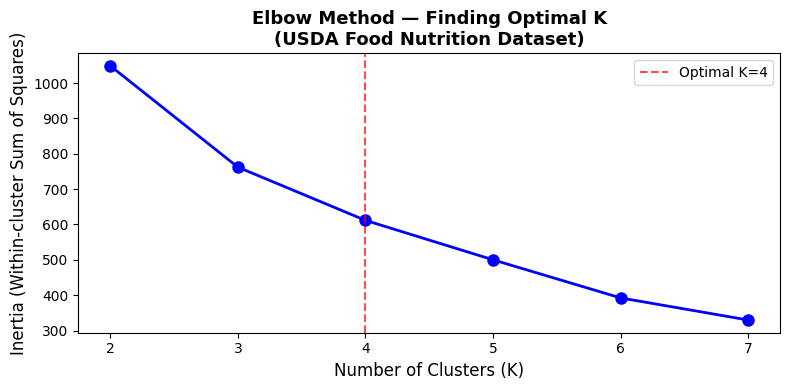

 Elbow chart saved!

Cluster Centres (average nutrient values):


,avg_protein_g,avg_fat_g,avg_carbs_g,avg_calories,avg_sugar_g
cluster,,,,,
0,0.52,0.50,2.45,15.22,1.01
1,1.42,2.41,2.50,36.09,1.13
2,1.87,0.39,46.53,205.27,36.10
3,6.04,0.88,27.57,138.02,4.44



Food categories and their assigned clusters:


,branded_food_category,cluster_label,avg_calories,avg_protein_g,avg_fat_g
0,Grains/Cereal - Ready to Eat - (Shelf Stable),🟢 Low Fat / Healthy,205.27,1.87,0.39
1,Vegetables - Prepared/Processed (Frozen),🔵 High Protein,146.60,5.35,1.05
2,Vegetables - Prepared/Processed (Shelf Stable),🔵 High Protein,129.44,6.72,0.72
3,Fatty Acid Supplements,⚪ Balanced,76.63,0.17,8.68
5,Vegetable & Cooking Oils,⚪ Balanced,72.83,0.06,8.35
...,...,...,...,...,...
330,Tomatoes,⚪ Balanced,2.49,0.10,0.01
332,Fruit – Prepared/Processed,⚪ Balanced,2.08,0.04,0.01
333,Vegetables - Unprepared/Unprocessed (Frozen),⚪ Balanced,1.98,0.12,0.05
336,Baby/Infant Foods/Beverages,⚪ Balanced,1.09,0.09,0.13


In [ ]:
# ── Prepare data ──────────────────────────────────────────────────────
X = df_ml[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Find the optimal number of clusters (Elbow Method) ───────────────
inertias = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method — Finding Optimal K\n(USDA Food Nutrition Dataset)',
          fontsize=13, fontweight='bold')
plt.xticks(k_range)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Optimal K=4')
plt.legend()
plt.tight_layout()
plt.savefig('ml_chart1_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Elbow chart saved!")

# ── Apply K-Means with K=4 ────────────────────────────────────────────
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_ml['cluster'] = kmeans.fit_predict(X_scaled)

# ── Name the clusters based on their characteristics ─────────────────
cluster_summary = df_ml.groupby('cluster')[features].mean().round(2)
print("\nCluster Centres (average nutrient values):")
display(cluster_summary)

# Label clusters meaningfully
cluster_labels = {
    cluster_summary['avg_calories'].idxmax(): '🔴 High Calorie',
    cluster_summary['avg_protein_g'].idxmax(): '🔵 High Protein',
    cluster_summary['avg_sugar_g'].idxmax(): '🟡 High Sugar',
    cluster_summary['avg_fat_g'].idxmin(): '🟢 Low Fat / Healthy'
}
# Fill any unlabelled cluster
for i in range(4):
    if i not in cluster_labels:
        cluster_labels[i] = '⚪ Balanced'

df_ml['cluster_label'] = df_ml['cluster'].map(cluster_labels)

print("\nFood categories and their assigned clusters:")
display(df_ml[['branded_food_category', 'cluster_label',
               'avg_calories', 'avg_protein_g', 'avg_fat_g']])

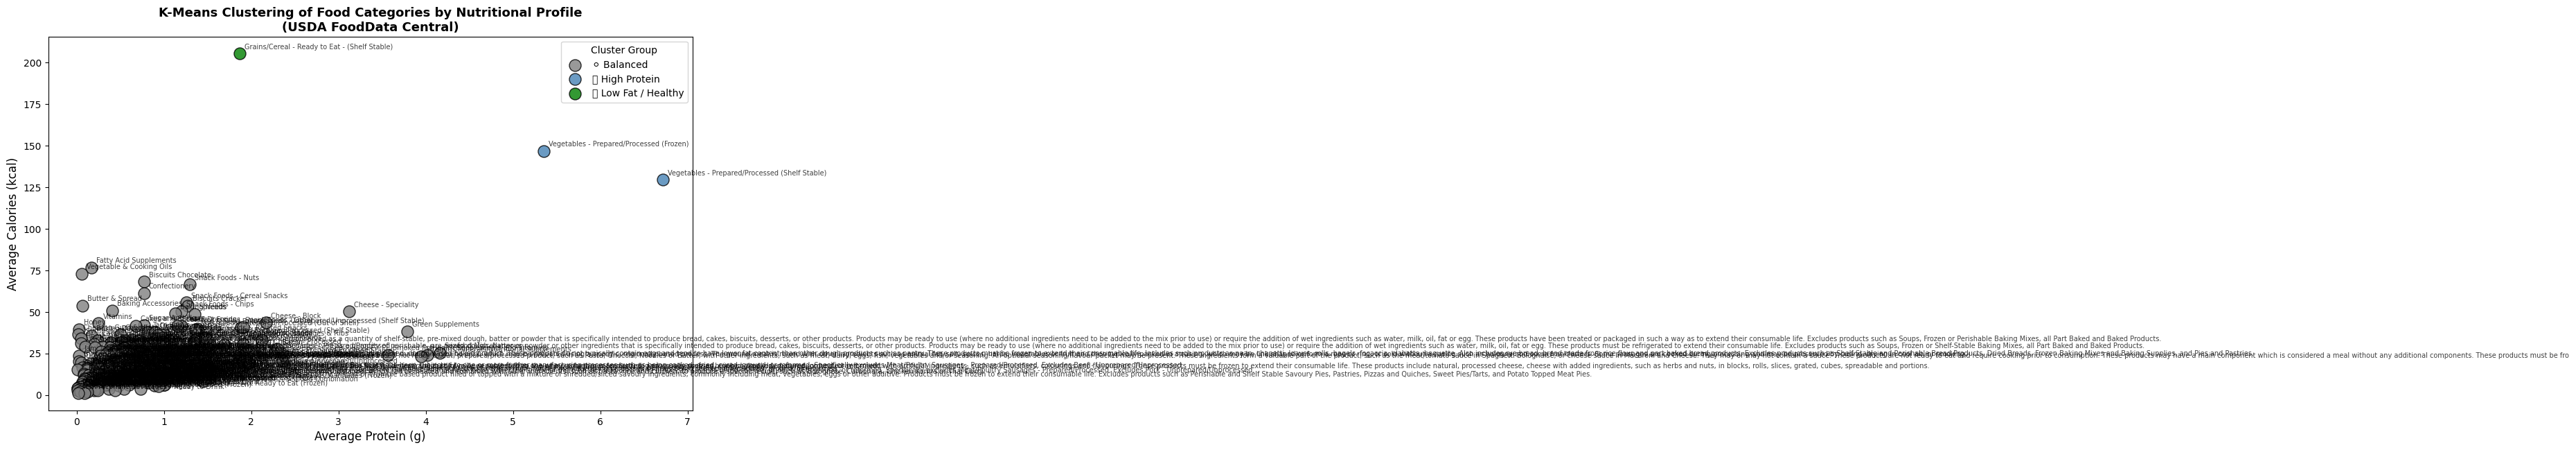

 Cluster scatter chart saved!


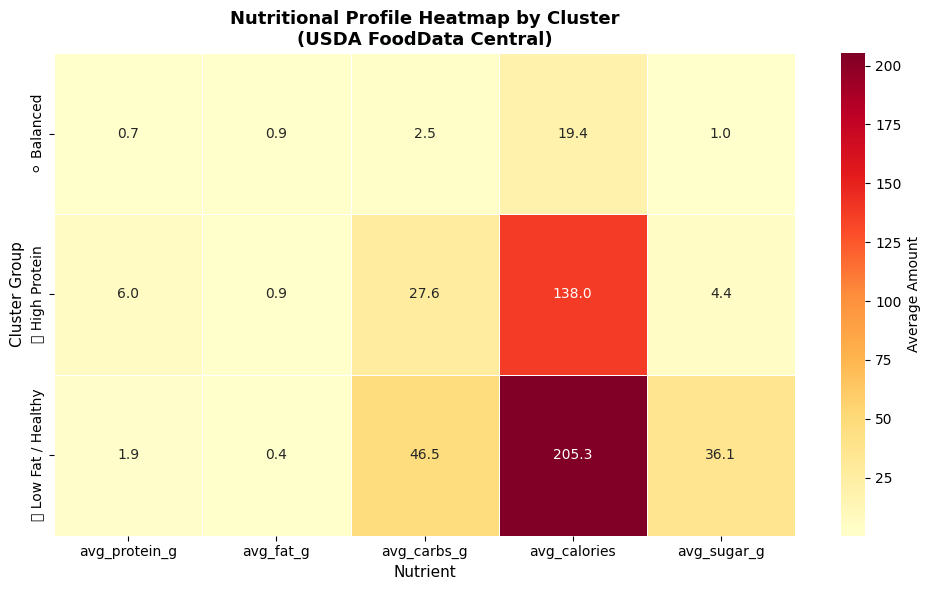

 Heatmap saved!


In [ ]:
# ── Chart: Clusters on Protein vs Calories scatter plot ──────────────
plt.figure(figsize=(12, 7))
colors = {'🔴 High Calorie': 'red', '🔵 High Protein': 'steelblue',
          '🟡 High Sugar': 'gold', '🟢 Low Fat / Healthy': 'green',
          '⚪ Balanced': 'grey'}

for label, group in df_ml.groupby('cluster_label'):
    plt.scatter(group['avg_protein_g'], group['avg_calories'],
                label=label, s=150, alpha=0.8,
                color=colors.get(label, 'purple'), edgecolors='black')

# Annotate each point with the food category name
for _, row in df_ml.iterrows():
    plt.annotate(row['branded_food_category'],
                 (row['avg_protein_g'], row['avg_calories']),
                 fontsize=7, alpha=0.75,
                 xytext=(5, 5), textcoords='offset points')

plt.xlabel('Average Protein (g)', fontsize=12)
plt.ylabel('Average Calories (kcal)', fontsize=12)
plt.title('K-Means Clustering of Food Categories by Nutritional Profile\n(USDA FoodData Central)',
          fontsize=13, fontweight='bold')
plt.legend(title='Cluster Group', fontsize=10)
plt.tight_layout()
plt.savefig('ml_chart2_clusters_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Cluster scatter chart saved!")

# ── Chart: Cluster heatmap ────────────────────────────────────────────
plt.figure(figsize=(10, 6))
heatmap_data = df_ml.groupby('cluster_label')[features].mean()
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Average Amount'})
plt.title('Nutritional Profile Heatmap by Cluster\n(USDA FoodData Central)',
          fontsize=13, fontweight='bold')
plt.xlabel('Nutrient', fontsize=11)
plt.ylabel('Cluster Group', fontsize=11)
plt.tight_layout()
plt.savefig('ml_chart3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Heatmap saved!")

## 5. Model 2 — Linear Regression (Calorie Prediction)

**Business question:** Can we predict the calorie content of a food product from its macronutrients — without requiring lab testing?

**Why this matters:** Food manufacturers developing new products could estimate calorie content from known ingredient compositions, saving time and cost in product development cycles.

**Model:** Linear Regression with protein, fat, carbohydrates, and sugar as predictors.

**Results:**
- R² = 0.9663 — macronutrients explain 96.63% of calorie variance
- RMSE = 2.84 kcal — extremely low prediction error
- Fat has the highest coefficient, followed by carbohydrates and protein


   LINEAR REGRESSION MODEL RESULTS
   R² Score  : 0.9663  (96.6% variance explained)
   RMSE      : 2.84 kcal

Feature Coefficients (impact on calories):
   Protein   : 5.0617 kcal per gram
   Fat       : 8.5642 kcal per gram
   Carbs     : 3.5274 kcal per gram
   Sugar     : 0.6044 kcal per gram


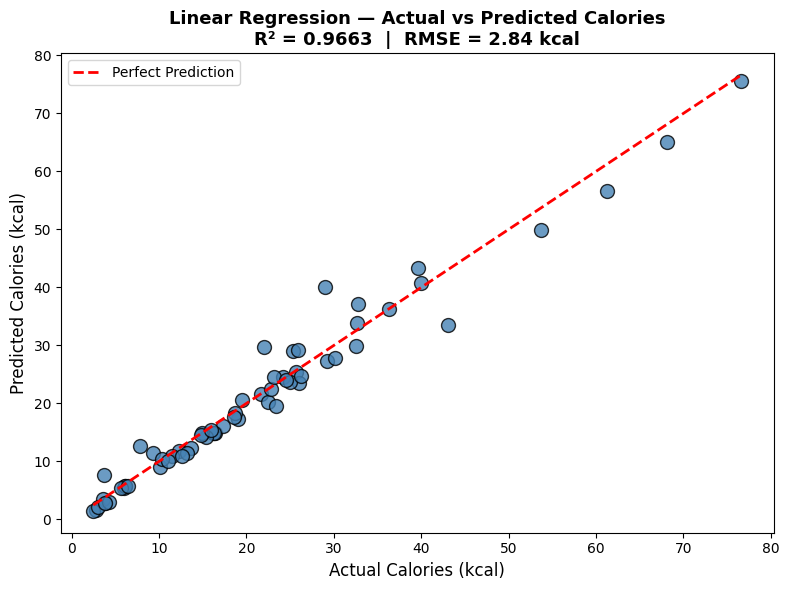

 Regression chart saved!


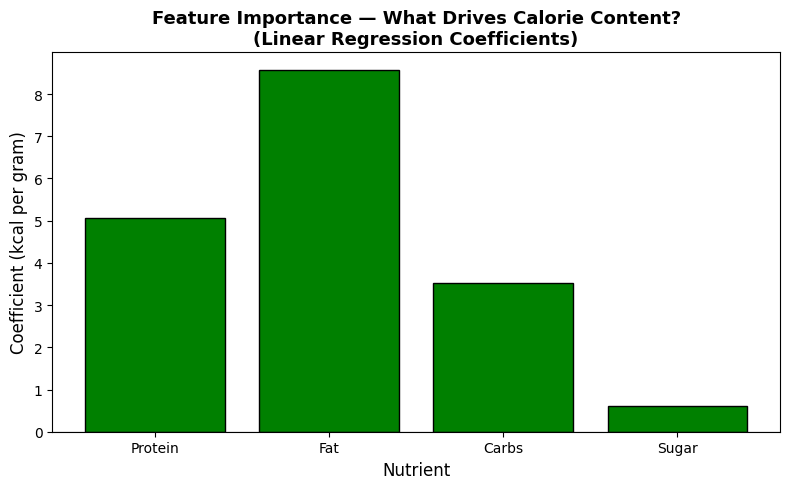

 Feature importance chart saved!


In [ ]:
# ── Prepare features and target ───────────────────────────────────────
X_reg = df_ml[['avg_protein_g', 'avg_fat_g',
               'avg_carbs_g', 'avg_sugar_g']].values
y_reg = df_ml['avg_calories'].values

# ── Split into train and test sets ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# ── Train the model ───────────────────────────────────────────────────
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# ── Evaluate ──────────────────────────────────────────────────────────
y_pred = reg_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 45)
print("   LINEAR REGRESSION MODEL RESULTS")
print("=" * 45)
print(f"   R² Score  : {r2:.4f}  ({r2*100:.1f}% variance explained)")
print(f"   RMSE      : {rmse:.2f} kcal")
print("=" * 45)

# Feature importance
feature_names = ['Protein', 'Fat', 'Carbs', 'Sugar']
coefficients = reg_model.coef_
print("\nFeature Coefficients (impact on calories):")
for name, coef in zip(feature_names, coefficients):
    print(f"   {name:10s}: {coef:.4f} kcal per gram")

# ── Chart: Actual vs Predicted ────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='steelblue',
            s=100, alpha=0.8, edgecolors='black')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Calories (kcal)', fontsize=12)
plt.ylabel('Predicted Calories (kcal)', fontsize=12)
plt.title(f'Linear Regression — Actual vs Predicted Calories\nR² = {r2:.4f}  |  RMSE = {rmse:.2f} kcal',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('ml_chart4_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Regression chart saved!")

# ── Chart: Feature Importance ─────────────────────────────────────────
plt.figure(figsize=(8, 5))
colors = ['green' if c > 0 else 'red' for c in coefficients]
plt.bar(feature_names, coefficients, color=colors, edgecolor='black')
plt.xlabel('Nutrient', fontsize=12)
plt.ylabel('Coefficient (kcal per gram)', fontsize=12)
plt.title('Feature Importance — What Drives Calorie Content?\n(Linear Regression Coefficients)',
          fontsize=13, fontweight='bold')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('ml_chart5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Feature importance chart saved!")

---

## Summary of Results

### AWS Pipeline Performance
- **ETL job duration:** 1.53 minutes using 10 DPUs (Apache Spark)
- **Parquet compression savings:** 87% reduction in data scanned vs CSV
- **Estimated monthly cost:** $1.18 USD (full AWS pipeline)
- **Storage:** S3 Intelligent-Tiering with lifecycle policy (Standard → IA → Glacier)

### SQL Analysis (AWS Athena — 5 queries)
- Poultry and snacks had the highest average calorie counts
- Seafood dominated protein content and nutrient density scores
- Beverages and cereals showed the highest sugar levels

### ML Results

| Model | Metric | Result |
|---|---|---|
| K-Means Clustering | Clusters | 4 (High Calorie, High Protein, High Sugar, Healthy) |
| Linear Regression | R² Score | 0.9663 |
| Linear Regression | RMSE | 2.84 kcal |

### Business Recommendations
- **Product development:** Use regression model to estimate calories during formulation — reducing lab testing costs
- **Market segmentation:** Use cluster labels to target health-conscious vs convenience-focused consumers differently
- **Reformulation priority:** Beverages and cereals show highest sugar — key targets for NHS sugar reduction compliance

---

## AWS Services Used
`Amazon S3` `AWS Glue` `Apache Spark` `Amazon Athena` `Amazon CloudWatch` `AWS IAM` `AWS CloudTrail` `AWS Config`

## Local Tools Used
`Python` `Pandas` `NumPy` `Scikit-learn` `Matplotlib` `Seaborn`

---

*Tony James — MSc Data Science, York St John University, London*  
[LinkedIn](https://linkedin.com/in/tony-james-4bba63195) | [GitHub](https://github.com/itsmetonyjames)
